In [1]:
import os
import random
from copy import deepcopy
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
import itpo_weights
from graph_utils import prepare_traj
from itpo_weights import DatasetType, ModelType
from pressure import compute_total_stress
from simulator_model import Model as VelocityModel
from training_utils import ModelInputs, freeze_normalizer
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    get_correct_edge_attr,
    load_and_split_dataset,
    simulate_then_rollout,
    specialized_rollout,
)

/home/sergey/work/gnn/GNNInverseDesign/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data

In [2]:
poisson_buckets = [
    {"max": 0.1, "count": 100},                # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 100},    # 0.1 <= P < 0.2
    {"min": 0.2, "count": 200}                 # P >= 0.2
]

dataset_type = DatasetType.NodeOptimized

train_files, val_files, test_files = load_and_split_dataset(
    registry_path="./data/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.7, 0.15, 0.15),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

print("Loading data...")
for key in data.keys():
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


Loading data...


test  data: 100%|██████████| 60/60 [00:02<00:00, 25.32it/s]



Preparing data...


test  data: 100%|██████████| 60/60 [00:05<00:00, 10.73it/s]


Train data: 280 sims.
Val data:   60 sims.
Test data:  60 sims.


#### Show $\nu$ distribution

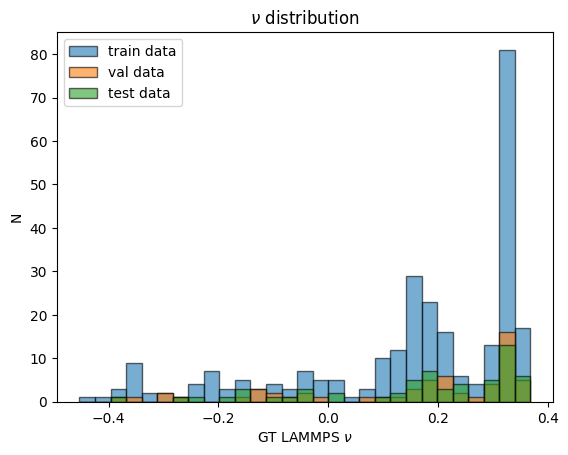

In [3]:
def visualize_nu_disribution(data: Dict):
    ps = {}
    all_values = []

    for data_type, sims in data.items():
        ps[data_type] = [calc_p_ratio_box_tensor(sim).item() for sim in sims]
        all_values.extend(ps[data_type])

    min_val = min(all_values)
    max_val = max(all_values)
    common_bins = np.linspace(min_val, max_val, 30) 

    for data_type, values in ps.items():
        plt.hist(
        values, 
        bins=common_bins, 
        edgecolor='black', 
        alpha=0.6, 
        label=f"{data_type} data"
    )

    plt.title("$\\nu$ distribution")
    plt.xlabel("GT LAMMPS $\\nu$")
    plt.ylabel("N")
    plt.legend()
    plt.show()

visualize_nu_disribution(data)


### Load pretrained models

In [8]:
simulator_type = ModelType.GNNModel # ModelType.GNNModel | ModelType.SimulatorCascade

dataset_type_map = {
    DatasetType.NodeOptimized: "node_optimized",
    DatasetType.StiffOptimized: "stiff_optimized",
}

match simulator_type:
    case ModelType.GNNModel:
        mp_layers = 2
        mlp = 3
        hidden_size = 128
        history = 3
        device = "cuda"

        init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, 4)))

        models = {}

        # model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        # model.load_checkpoint(f"./trained_models/{dataset_type_map[dataset_type]}/OST/model_P>0.2_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
        # model = freeze_normalizer(model)
        # models[f"h{history} P>0.2 ost"] = model

        # model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        # model.load_checkpoint(f"./trained_models/{dataset_type_map[dataset_type]}/OST/model_P>0.1_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
        # model = freeze_normalizer(model)
        # models[f"h{history} P>0.1 ost"] = model

        model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        model.load_checkpoint(f"./trained_models/{dataset_type_map[dataset_type]}/MST/model_P>0.2_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
        model = freeze_normalizer(model)
        models[f"h{history} P>0.2 mst"] = model

        model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
        model.load_checkpoint(f"./trained_models/{dataset_type_map[dataset_type]}/MST/model_P>0.1_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
        model = freeze_normalizer(model)
        models[f"h{history} P>0.1 mst"] = model

        for i, model_name in enumerate(models.keys()):
            print(f"{i+1}. Model {model_name}.")

    case ModelType.SimulatorCascade:
        hidden_size = 128
        mp_layers = 2
        mlp = 3
        epochs = 100

        device = 'cuda'
        model_save_path = os.path.join("./trained_models", f"{dataset_type_map[dataset_type]}", "cascade", "refined_P>0.2")
        n_models = len(os.listdir(model_save_path))

        models = []
        for h in tqdm(range(n_models)):
            if h == 0:
                n_graphs = 1
            else:
                n_graphs = h+1
            
            init_graph = build_velocity_graph_correction([data['val'][0][i].cpu().detach() for i in range(n_graphs)], panic_at_positions=False).to(device)

            current_h_model = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
            current_h_model.load_checkpoint(os.path.join(model_save_path, f"model_refined_h{h}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))
            current_h_model = freeze_normalizer(current_h_model)
            for param in current_h_model.parameters():
                param.requires_grad = False
            models.append(current_h_model)

        print(f"Loaded cascade of {len(models)} pretrained models.")    


1. Model h3 P>0.2 mst.
2. Model h3 P>0.1 mst.


### Test ITPO - Bootstrapped GNN Simulator

In [9]:
%run utils.py

In [10]:
factors = [(sim[4].box_tensor[0]/sim[3].box_tensor[0]).item() for sim in data["val"]]
mean_factor = sum(factors)/len(factors)

weights = itpo_weights.get_params(simulator_type, dataset_type)

num_steps = 50
max_name_len = max([len(n) for n in models.keys()])+1 
    

model_results = {}
for model_name, model in models.items():

    model.eval()
    history = int(model_name[1])
    target_idx = num_steps + history + 1

    local_results = {}
    for mode in ('itpo', 'default'):
        results = {
            "mse": [],
            "pred_p": [],
            "pred_p_function": [],
            "gt_p": [],
            "gt_p_function": [],
            "gt_box": [],
            "pred_box": [],
            "gt_pressure": [],
            "pred_pressure": [],
        }

        with torch.no_grad():
            for val_sim in tqdm(data['test'][:30], desc=f"Model {model_name:<{max_name_len}}"):

                # Compute dumping period (N MD steps in 1 dump step)        
                sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
                assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
                dump_period = int(assumed_rollout_length / len(val_sim)) + 1

                input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]
                
                barostat_config = barostat_parameters.node_optimizated if dataset_type is DatasetType.NodeOptimized else barostat_parameters.stiff_optimized

                if mode == 'default':
                    rollout = simulate_then_rollout(
                        starting_graph=input_graphs[0],
                        gnn_simulator=model,
                        rollout_steps=num_steps,
                        gnn_history=history,
                        barostat_config=barostat_config,
                        md_steps=(dump_period*history)+1,
                        device="cuda"
                    )
                elif mode == 'itpo':
                    rollout = specialized_rollout(
                        starting_graph=input_graphs[0],
                        gnn_simulator=model,
                        gnn_history=history,
                        barostat_config=barostat_config,
                        itpo_weights=weights,
                        md_steps=(dump_period*history)+1,
                        rollout_steps=num_steps,
                        device="cuda"
                    )
                
                # Compute position MSE
                pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
                results["mse"].append(pos_mse)
                
                # Compute predicted and GT Poisson's ratio
                pred_p = calc_p_ratio_box_tensor(rollout).item()
                results["pred_p"].append(pred_p)
                gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
                results["gt_p"].append(gt_p)

                # Poisson's ratio as a function of rollout step
                gt_p_change = [calc_p_ratio_box_tensor(val_sim[:i]).item() for i in range(1, target_idx)]
                results["gt_p_function"].append(gt_p_change)
                pred_p_change = [calc_p_ratio_box_tensor(rollout[:i]).item() for i in range(1, target_idx)]
                results["pred_p_function"].append(pred_p_change)

                # Periodic box behaviour
                pred_box = [g.box_tensor.cpu() for g in rollout]
                results["pred_box"].append(pred_box)
                gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
                results["gt_box"].append(gt_box)

                # Compute pressure
                r0 = rollout[0].edge_attr[:, -2]
                gt_pressure = torch.stack([compute_total_stress(g, r0=r0, temperature=1e-7).cpu() for g in val_sim[: len(rollout)]], dim=0)
                results['gt_pressure'].append(gt_pressure)
                pred_pressure = torch.stack([compute_total_stress(g, r0=r0, temperature=1e-7).cpu() for g in rollout], dim=0)
                results["pred_pressure"].append(pred_pressure)

        local_results[mode] = results

    model_results[model_name] = local_results


Model h3 P>0.1 mst : 100%|██████████| 30/30 [00:17<00:00,  1.75it/s]


### Test ITPO - Simulator Cascade

In [ ]:
factors = [(sim[4].box_tensor[0]/sim[3].box_tensor[0]).item() for sim in data["val"]]
mean_factor = sum(factors)/len(factors)
print(f"Mean box compression factor: {mean_factor:.6e}")

num_steps = 50
target_idx = num_steps
total_models = {
    # 'P > 0.2' : very_high_p_models,
    'P > 0.1' : high_p_models,
}

if dataset_type == 'dePablo':
    # dePablo data weights
    REFINEMENT_ITERATIONS = 50
    LR = 2.4347939215508626e-06

    physical_loss_weights = {
        'lambda_force'   : 0.2571693753028027,
        'lambda_energy'  : 3.0716147827138016e-07,
        'lambda_pressure': 0.000396262687255812
    }

elif dataset_type == 'Reid-like':
    # Reid data weights
    REFINEMENT_ITERATIONS = 35
    LR = 3.0199055709794887e-05
    physical_loss_weights = {
        'lambda_force'    : 0.004990635231284185,
        'lambda_energy'   : 6.667337380211805e-05,
        'lambda_pressure' : 0.00032247351656595965,
    }    

else:
    raise NotImplementedError('Incorrect data type')


# # Best combined models weights from refined models > 0.2
# REFINEMENT_ITERATIONS = 18
# LR = 1.1936843770658332e-06

# physical_loss_weights = {
#     'lambda_force'    : 3.02584144218195e-06,
#     'lambda_energy'   : 1.3239447697833233e-05,
#     'lambda_pressure' : 0.0008840692039858846,
# }

model_results = {}
for model_name, current_models in total_models.items():

    local_results = {}
    for mode in ('tto', 'default'):
        results = {
            "gt_box_velocity": [],
            "pred_box_velocity": [],
            "final_mse": [],
            "mse": [],
            "est_p": [],
            "pred_p": [],
            "pred_p_function" : [],
            "gt_est_p": [],
            "gt_p": [],
            "gt_p_function" : [],
            "gt_box": [],
            "pred_box": [],
            "gt_forces": [],
            "pred_forces": [],
            "gt_pressure": [],
            "pred_pressure": [],
        }

        with torch.no_grad():
            for val_sim in tqdm(data['test'][:25]+data['val'][:25]+data['ft'][:25]+data['train'][:25]):

                # This block computes dumping period (N MD steps in 1 dump step)        
                sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
                assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
                dump_period = int(assumed_rollout_length / len(val_sim)) + 1
                dump_period = 200

                if dataset_type == 'dePablo':
                    barostat_config = {
                        "dt" : 0.01,
                        "default_skip" : dump_period,
                        "C_coupling" : 14.3,
                        "damping" : 3.34,
                        "temperature" : 0.0,
                        "target_pressure" : 0.0,
                    }

                elif dataset_type == 'Reid-like':
                    barostat_config = {
                        "dt" : 0.01,
                        "default_skip" : dump_period,
                        "C_coupling" : 10.0,
                        "damping" : 5.00,
                        "temperature" : 0.0,
                        "target_pressure" : 0.0,
                    }

                else:
                    raise NotImplementedError("Incorrect data type")
                
                if mode == 'default':
                    rollout = rollout_cascade(
                        models=current_models,
                        initial_state=val_sim[0].cpu().detach(),
                        num_steps=num_steps,
                        barostat_config=barostat_config,
                        box_compression_factor=mean_factor,
                        device='cuda'
                    )
                elif mode == 'tto':
                    rollout = specialized_rollout_cascade(
                        starting_graph=val_sim[0].cpu().detach(),
                        gnn_models=current_models,
                        barostat_config=barostat_config,
                        box_compression_factor=mean_factor,
                        physical_losses_weights=physical_loss_weights,
                        refinement_iterations=REFINEMENT_ITERATIONS,
                        refinement_learning_rate=LR,
                        rollout_steps=num_steps,
                        device='cuda'
                    )
                
                # Compare Predicted Position vs Ground Truth Position
                pos_mse = torch.nn.functional.mse_loss(rollout[-1].pos.cpu(), val_sim[target_idx].to(device).pos.cpu()).item()
                results["final_mse"].append(pos_mse)
                pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
                results["mse"].append(pos_mse)
                
                est_p = estimate_p(rollout).item()
                results["est_p"].append(est_p)
                pred_p = calc_p_ratio_box_tensor(rollout).item()
                results["pred_p"].append(pred_p)
                gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
                results["gt_p"].append(gt_p)
                gt_est_p = estimate_p(val_sim[:target_idx]).item()
                results["gt_est_p"].append(gt_est_p)
                
                pred_box = [g.box_tensor.cpu() for g in rollout]
                results["pred_box"].append(pred_box)
                gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
                results["gt_box"].append(gt_box)


                # P as a function of rollout step
                gt_p_change = [calc_p_ratio_box_tensor(val_sim[:i]).item() for i in range(1, target_idx)]
                results["gt_p_function"].append(gt_p_change)
                pred_p_change = [calc_p_ratio_box_tensor(rollout[:i]).item() for i in range(1, target_idx)]
                results["pred_p_function"].append(pred_p_change)

                # gt_forces = val_sim[target_idx].forces
                # results["gt_forces"].append(gt_forces.cpu().detach())
                # pred_forces = rollout[-1].forces
                # results["pred_forces"].append(pred_forces.cpu().detach())
                # gt_pressure = torch.stack([compute_total_stress(g, temperature=1e-7).cpu() for g in val_sim[: len(rollout)]], dim=0)
                # results['gt_pressure'].append(gt_pressure)
                # pred_pressure = torch.stack([compute_total_stress(g, temperature=1e-7).cpu() for g in rollout], dim=0)
                # results["pred_pressure"].append(pred_pressure)


        local_results[mode] = results

    model_results[model_name] = local_results

### Plotting

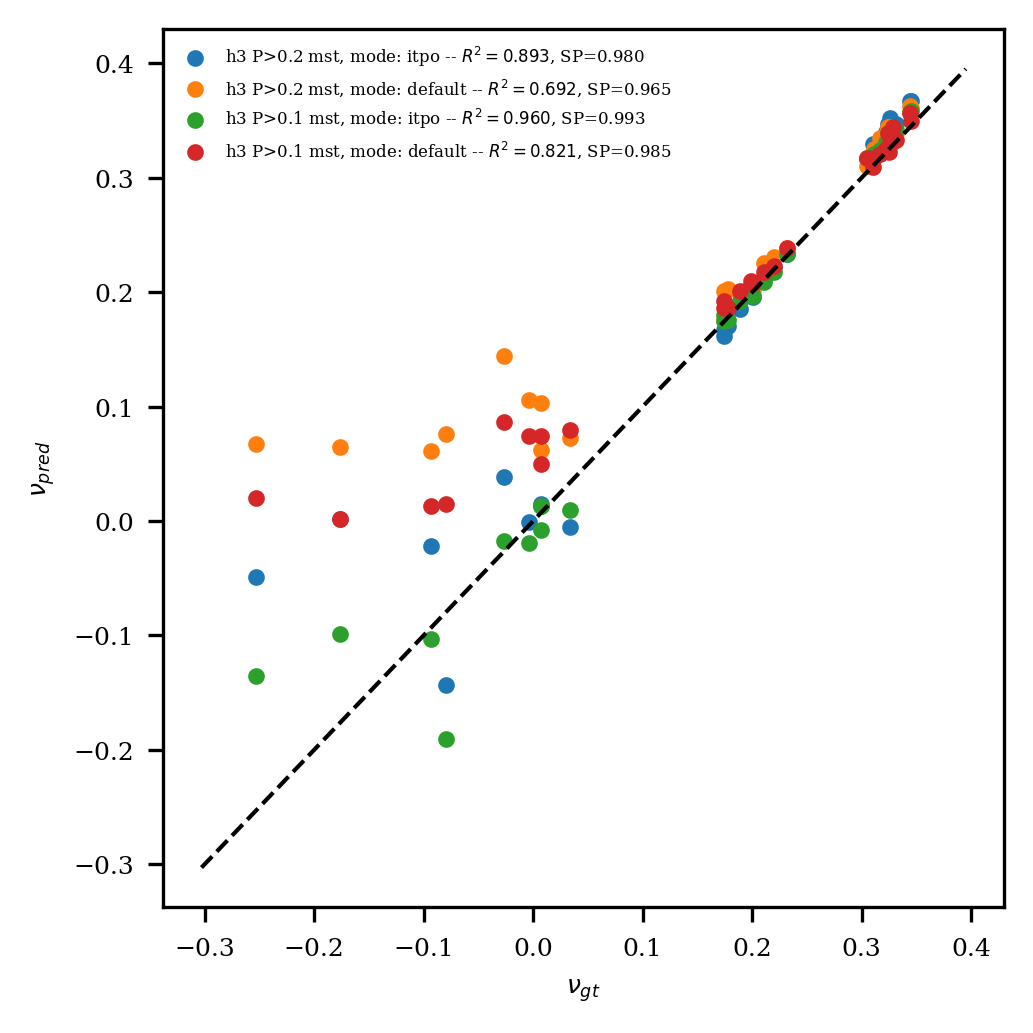

In [12]:
params = {
    'font.size': 6,                 # Base font size
    'axes.labelsize': 6,            # Axis labels
    'axes.titlesize': 6,            # Subplot titles
    'xtick.labelsize': 6,           # Tick x numbers
    'ytick.labelsize': 6,           # Tick y numbers
    'legend.fontsize': 4,           # Make legend smaller to fit
    'lines.markersize': 3,          # Reduce scatter dot size
    'figure.figsize': (3.33, 3.33), # Target figure size in inches
    'figure.dpi': 300,              # DPI
    'font.family': 'serif',         # Font
}
plt.rcParams.update(params)

fig, ax = plt.subplots(1, 1, layout="constrained")

gt_p = model_results[sorted(model_results.keys())[0]]['default']['gt_p']
line = (min(gt_p) - 0.05, max(gt_p) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, local_results in model_results.items():
    for mode, results in local_results.items():
        r2 = r2_score(results['gt_p'], results['pred_p'])
        res = spearmanr(results["gt_p"], results["pred_p"])
        sp = res.statistic
        label_text = f"{model_name}, mode: {mode} -- $R^2={r2:.3f}$, SP={sp:.3f}"
        ax.scatter(results["gt_p"], results["pred_p"], label=label_text)

ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")

plt.show()


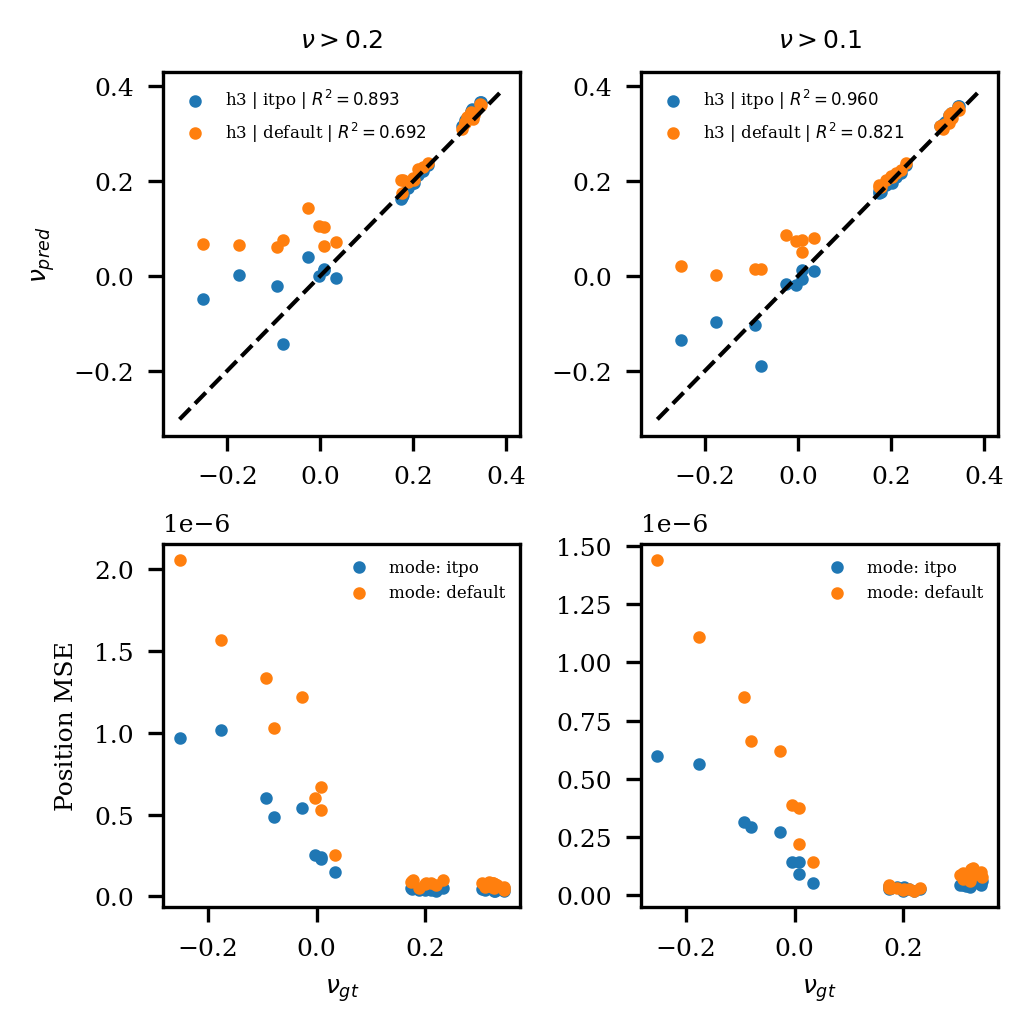

In [22]:
params = {
    'font.size': 6,                 # Base font size
    'axes.labelsize': 6,            # Axis labels
    'axes.titlesize': 6,            # Subplot titles
    'xtick.labelsize': 6,           # Tick x numbers
    'ytick.labelsize': 6,           # Tick y numbers
    'legend.fontsize': 4,           # Make legend smaller to fit
    'lines.markersize': 2,          # Reduce scatter dot size
    'figure.figsize': (3.33, 3.33), # Target figure size in inches
    'figure.dpi': 300,              # DPI
    'font.family': 'serif',         # Font
}
plt.rcParams.update(params)

fig, ax = plt.subplots(2, 2, layout="constrained")

line = (min(results["gt_p"]) - 0.05, max(results["gt_p"]) + 0.05)
ax[0][0].plot(line, line, color="black", linewidth=1, linestyle='--')
ax[0][1].plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, local_results in model_results.items():
    if 'P>0.2' in model_name:
        active_ax = ax[0][0]
        active_ax.set_title(r'$\nu > 0.2$')
    else:
        active_ax = ax[0][1]
        active_ax.set_title(r'$\nu > 0.1$')
    for mode, results in local_results.items():
        r2 = r2_score(results['gt_p'], results['pred_p'])
        res = spearmanr(results["gt_p"], results["pred_p"])
        sp = res.statistic
        # label_text = f"{model_name}, mode: {mode} -- $R^2={r2:.3f}$, SP={sp:.3f}"
        # label_text = f"{model_name[2:]} | {mode} | $R^2={r2:.3f}$"
        label_text = f"{model_name[:2]} | {mode} | $R^2={r2:.3f}$"
        # label_text = f"mode: {mode} -- $R^2={r2:.3f}$, SP={sp:.3f}"
        active_ax.scatter(results["gt_p"], results["pred_p"], label=label_text)
        active_ax.legend(frameon=False, loc='best')

for model_name, local_results in model_results.items():

    if 'P>0.2' in model_name:
        active_ax = ax[1][0]
    else:
        active_ax = ax[1][1]
    
    for mode, results in local_results.items():
        r2 = r2_score(results['gt_p'], results['pred_p'])
        res = spearmanr(results["gt_p"], results["pred_p"])
        sp = res.statistic
        label_text = f"mode: {mode}"
        active_ax.scatter(results["gt_p"], [m[-1] for m in results["mse"]], label=label_text)
        active_ax.legend(frameon=False, loc='best')
        # active_ax.set_yscale('log')


ax[1][0].set_xlabel(r"$\nu_{gt}$")
ax[1][1].set_xlabel(r"$\nu_{gt}$")
ax[0][0].set_ylabel(r"$\nu_{pred}$")
ax[1][0].set_ylabel("Position MSE")


plt.show()
# fig.savefig("paper_figures/TTO_combined_models.png", format='png')

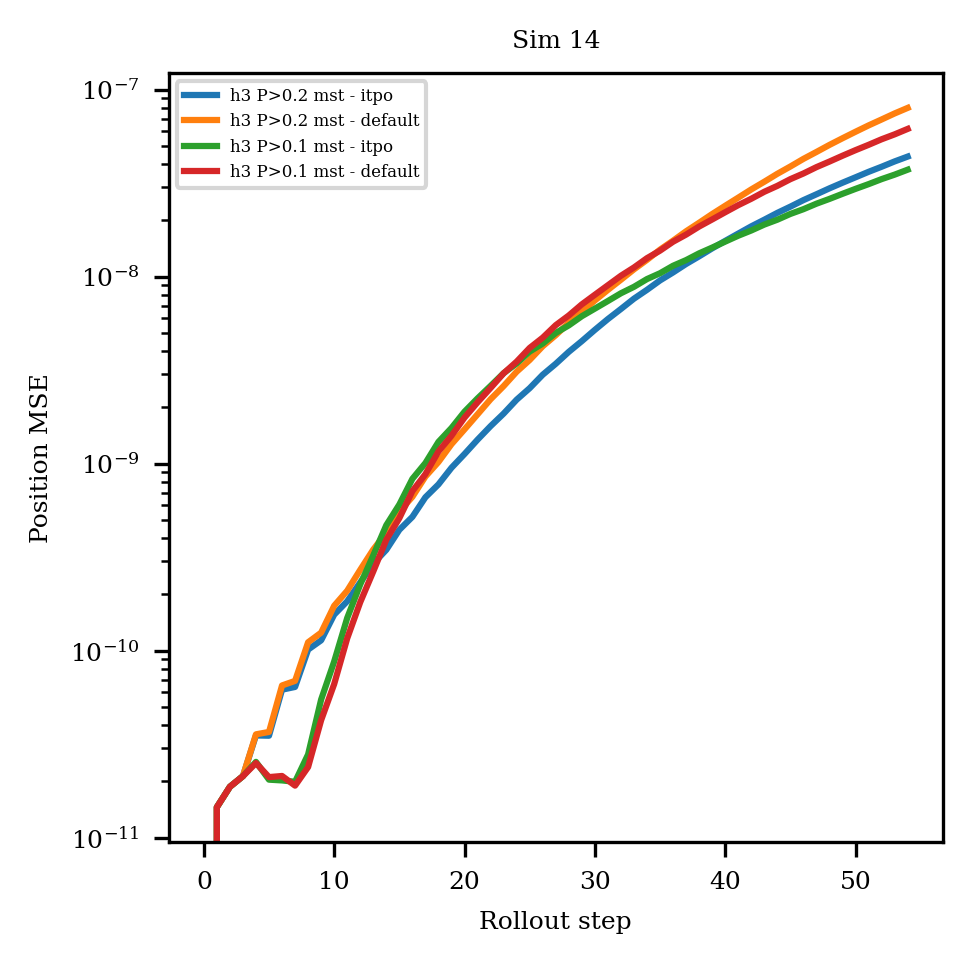

In [26]:
rand_sim = random.randint(0, len(results['mse'])-1)

label_map = {
    'itpo' : 'itpo',
    'default' : 'default',
}

for model_name, local_results in model_results.items():
    for mode, results in local_results.items():
        plt.plot(results["mse"][rand_sim], label=f"{model_name} - {label_map[mode]}")

plt.legend()
plt.title(f"Sim {rand_sim}")
plt.xlabel('Rollout step')
plt.ylabel('Position MSE')
plt.yscale('log')
plt.show()

In [27]:
model_results.keys()

dict_keys(['h3 P>0.2 mst', 'h3 P>0.1 mst'])

In [ ]:
rand = random.randint(0, 60)

local_results = model_results['h3 special training P > 0.1']

tto_results = local_results['tto']
default_results = local_results['default']

box_y_true = [default_results["gt_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
box_x_true = [default_results["gt_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

box_y_roll_tto = [tto_results["pred_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
box_x_roll_tto = [tto_results["pred_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

box_y_roll_default = [default_results["pred_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
box_x_roll_default = [default_results["pred_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]


fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(6, 3))

ax[0].plot(box_y_true, label="Ly GT")
ax[0].plot(box_y_roll_tto, label="Ly rollout")
ax[0].set_title('Inference correction')
ax[0].legend()

ax[1].plot(box_y_true, label="Ly GT")
ax[1].plot(box_y_roll_default, label="Ly rollout")
ax[1].set_title('Default')
ax[1].legend()

plt.show()

### Plotting - r2 and mse as a function of step

In [ ]:
model_results.keys()

In [ ]:
# plt.scatter(model_results['h3 special training P > 0.1']['tto']['gt_p_function'][0], model_results['h3 special training P > 0.1']['tto']['pred_p_function'][0])

i = random.randint(0, 99)
for model_name, result in model_results.items():
    plt.plot(result['tto']['gt_p_function'][i], label='gt')
    plt.plot(result['tto']['pred_p_function'][i], label='tto')
    plt.plot(result['default']['pred_p_function'][i], label='default')
    plt.ylabel(r'$\nu$')
    plt.xlabel('step')
    plt.legend()

plt.show()

In [ ]:
import numpy as np

r2s = {
    'tto': [],
    'default': [],
}

for model_name, result in model_results.items():
    for step in range(1, num_steps-1):
        for mode in ('tto', 'default'):
            pred_p_to_step = [p[step] for p in result[mode]['pred_p_function']]
            gt_p_to_step = [p[step] for p in result[mode]['gt_p_function']]
            
            r2 = r2_score(gt_p_to_step, pred_p_to_step)
            r2s[mode].append(r2)

steps = np.array(range(20, 191, 20))
width = 6.0  # Slightly narrower than 8.0 to leave a small gap between groups

# Calculate offsets
# We shift one bar left by width/2 and the other right by width/2
plt.bar(steps - width/2, [r2s['tto'][i] for i in steps],     width=width, label='ITPO')
plt.bar(steps + width/2, [r2s['default'][i] for i in steps], width=width, label='default')

plt.legend()
plt.xlabel('Rollout step')
plt.ylabel('$R^2$')
plt.xticks(steps)
plt.show()

In [ ]:
mses = {
    'tto': [],
    'default': [],
}
for step in range(1, num_steps-1):
    for mode in ('tto', 'default'):
        mse = [p[step] for p in model_results['P > 0.1'][mode]['mse']]
        mse = sum(mse) / len(mse)

        mses[mode].append(mse)

steps = np.array(range(20, 191, 20))
width = 6.0  # Slightly narrower than 8.0 to leave a small gap between groups

# Calculate offsets
# We shift one bar left by width/2 and the other right by width/2
plt.bar(steps - width/2, [mses['tto'][i] for i in steps],     width=width, label='ITPO')
plt.bar(steps + width/2, [mses['default'][i] for i in steps], width=width, label='default')

plt.legend()
plt.xlabel('Rollout step')
plt.ylabel('Position MSE')
plt.yscale('log')
plt.xticks(steps)
plt.show()